#IMPORTANT POINT 1
You can't modify this notebook. For this reason, *you need to copy the notebook to your drive. To this end, please go to File->Save a copy in Drive*.

You can make a special folder for the course in your drive. Then, use that copied version.

#IMPORTANT POINT 2
Colab grants us access to GPUs, which makes ANN training much faster. However, after a few hours, access is revoked and we have to wait. For this session, we will not train huge networks, so do not worry if you get a message saying that your GPU hours have been used up. You'll get new GPU hours after a little while.

#<font color='red'>IMPORTANT POINT 3</font>
<font color='red'>We will use big networks today. They will take quite long to run on the CPU.
To this end:
1. go to the little drop-down menu just below "Comment" in the top right of the screen.
2. Select "Change runtime type"
3. Select GPU </font>

<font color='red'>With that done, let's dig in.</font>

---

#Week 5: Extracting activities & Big pretrained networks
Author: Adrien Doerig

\
First, we will start by learning about how to extract activities from different layers of neural networks.

Second, up to now, we have been using custom-created little networks. But we can also download and use big networks pre-trained by others! We'll learn how to do that, and how to extract activities from these models, which will be needed later when we'll do encoding models / RSA to compare ANNs and brains.

---

###Import python packages required for this notebook
***You need to run this cell for the rest of the notebook to work!***


In [2]:
import torch                              # <- PyTorch
from torch.utils.data import DataLoader
from torch import nn
import torchvision                        # Torch stuff for Computer vision
from torchvision import transforms

import os
import matplotlib.pyplot as plt           # Plotting library
import numpy as np                        # Mathy functions on CPU
from tqdm.notebook import tqdm            # Library to make progress bars

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


##Picking up where we left off

The following code cells are useful functionsa copy-pasted from previous weeks.

>Note: This is copy-pasted code from previous sessions. Feel free to go over it as a recap if you want, but this is not the focus for today.

Create simple MLP model.

In [3]:
# nn.Module is the base class for all neural network modules in PyTorch.
# Our SimpleMLP inherits from it.
class SimpleMLP(nn.Module):

    # __init__() method in initializes the layers and attributes of the
    # neural network when an instance is created.
    # Basically, we define all the "building blocks" we need here, and we will
    # combine them in the forward(x) function.
    def __init__(self, n_input_pixels, n_hidden):
        super().__init__()
        self.flatten = nn.Flatten()              # Converts the input image of shape (channels, heigh, width) into a flattened vector of 784 elements.
        self.hidden = nn.Linear(n_input_pixels, n_hidden) # Hidden layer
        self.relu = nn.ReLU()                    # Activation function
        self.output = nn.Linear(n_hidden, 10)    # Output layer
        self.softmax = nn.Softmax(dim=1)         # Activation function

    # forward(x) defines the forward pass of the model, specifying how
    # input x flows through the layers to produce the output.
    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.softmax(x)
        return x

training & testing functions

In [4]:
def test(model, loader, criterion, device):
    '''
    model: a pytorch model instance
    loader: a pytorch DataLoader instance
    criterion: a pytorch loss function instance
    device: 'cuda' or 'cpu'
    '''

    # Set the model to evaluation mode. Again, this is important when using
    # more complex ingredients, such as BatchNorm or Dropout, which we are not
    # using here. Still, it is good to get into the habit.
    model.eval()

    # initialize the values we'll report
    test_loss = 0 # this is for the cross-entropy loss
    correct = 0 # we'll get a %correct accuracy
    total = 0 # this is to count the total number of test examples seen.

    # Disable gradient calculation (i.e., we don't keep track of which units
    # impact the loss as we don't want to learn with gradient descent during
    # testing).
    with torch.no_grad():

        # Loop over the testing dataloader, with a nice tqdm progressbar
        for item in tqdm(loader):

            inputs, labels = item[0], item[1]
            inputs = inputs.to(device)
            labels = labels.to(device)

            # pass data through model
            outputs = model(inputs)

            # add loss to total test loss
            test_loss += criterion(outputs, labels).item() # note: a += b is the same as a = a+b

            # to compute the accuracy, we need to get the output with the
            # highest value (this is the network's prediction)
            _, predicted = torch.max(outputs.data, 1)
            # this is a logical operation to get the number of items
            # where the prediction matches the label
            correct += (predicted == labels).sum().item()

            # keep track of how many test samples we've seen
            total += labels.size(0)

    test_loss /= len(loader) # report average loss per batch
    accuracy = 100 * correct / total # report percent correct
    print(f"Test Loss: {test_loss:.4f}, Accuracy: {accuracy:.2f}%")

    return test_loss, accuracy


# improve our training function to print the test loss after each epoch.
def train_and_test(model, dataloader_train, dataloader_test, n_epochs, criterion, optimizer, device):
    '''
    model: a pytorch model instance
    dataloader_train: a pytorch DataLoader instance for training
    dataloader_test: a pytorch DataLoader instance for testing
    n_epochs: number of epochs to train for
    criterion: a pytorch loss function instance
    optimizer: a pytorch optimizer instance
    device: 'cuda' or 'cpu'
    '''

    history = []

    # We loop over the whole training dataset n_epochs times
    for epoch in range(n_epochs):

        print(f"Epoch {epoch + 1}/{n_epochs}")

        # Set the model to training mode.
        model.train(True)

        # Do training loop.
        # THIS IS ESSENTIALLY THE SAME AS OUR PREVIOUS TRAINING FUNCTION
        for i, item in enumerate(tqdm(dataloader_train, desc=f"Epoch {epoch + 1}")):
            optimizer.zero_grad()  # Set all gradients to 0
            inputs, labels = item[0], item[1]  # Pair of input and corresponding label
            inputs = inputs.to(device)         # Move to desired device (GPU/CPU)
            labels = labels.to(device)         # Move to desired device (GPU/CPU)
            outputs = model(inputs)            # Feed the input through the model
            batch_loss = criterion(outputs, labels)  # Calculate the loss
            history.append(batch_loss.cpu().detach().numpy())
            batch_loss.backward()  # Calculate the gradient for the current loss
            optimizer.step()
            # Print the current batch loss every few batches
            if i%5==0:
              tqdm.write(f"\rBatch Loss: {batch_loss.item()}", end='')

        # After each epoch, evaluate the model on the test set
        test_loss, accuracy = test(model, dataloader_test, criterion, device)

    return history

Define helper functions for plotting

In [5]:
def plot_batch_predictions(model, loader, n_imgs):
    # Get a batch of images and labels from the dataloader
    img_batch, label_batch = next(iter(loader))

    # if we only have one color channel, use a grayscal colormap
    # otherwise, use the standard 3-channel one
    if img_batch.shape[1] == 1:
      colormap = 'gray'
    else:
      colormap = None

    # Pass the images through the model to get the predicted labels
    predicted_labels = model(img_batch)

    # Make plot with predicted vs. true labels
    # we'll have max 10 images per row
    n_rows = int(np.ceil(n_imgs/10))
    n_cols = min(10, n_imgs)
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols,n_rows*1.5))
    if n_rows == 1:
        # Need to make sure ax is 2D array even when there is a single row
        # Otherwise we get wrong indexing in the for loop below
        ax = np.expand_dims(ax, axis=0)

    for i in range(n_imgs):
        row, col = i//10, i%10
        ax[row, col].imshow(img_batch[i].permute(1,2,0), cmap=colormap)
        ax[row, col].set_title(f'pred={torch.argmax(predicted_labels[i])}\ntrue={label_batch[i]}')
        ax[row, col].set_xticks([])
        ax[row, col].set_yticks([])


def plot_dataset_samples(loader, n_imgs):

    # get data from dataloader
    example_data, example_labels = next(iter(loader))

    # if we only have one color channel, use a grayscal colormap
    # otherwise, use the standard 3-channel one
    if example_data.shape[1] == 1:
      colormap = 'gray'
    else:
      colormap = None

    # Make plot with predicted vs. true labels
    # we'll have max 10 images per row
    n_rows = int(np.ceil(n_imgs/10))
    n_cols = min(10, n_imgs)
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols,n_rows*1.5))
    if n_rows == 1:
        ax = np.expand_dims(ax, axis=0)

    for i in range(n_imgs):
        this_img = example_data[i].permute(1,2,0)
        row, col = i//10, i%10
        ax[row, col].imshow(this_img, cmap=colormap)
        ax[row, col].set_title(f"Label: {example_labels[i]}")
        ax[row, col].set_xticks([])
        ax[row, col].set_yticks([])
        plt.title('Train loss')
    plt.show()

##Let's dive in

We will cover two main topics today:

1. How to retrieve and analyse network activities on a small model like we are used to.

2. Download big models from the internet and analyse their activities.

#Analysing network activities
In the coming weeks, we will be interested in analysing the "neural" activations of ANNs, and compare them to neural activities in the brain.

As a first step, we will retrieve activities in different layers of our networks on the test set. We will apply dimensionality reduction and representational similarity analysis to visualize the neural space and see which layers (if any) learn to represent similar digits similarly.

##Exercise 1:
Create a simple MLP model (use the function copy-pasted above from previous weeks) and train it on MNIST.

We have done this many times, so I'm not helping you out. Look at previous sessions if needed.

>**Note:** Apply normalisation and data augmentation to the training set if you want to, but this is not a requirement since it is not the topic for today.

Epoch 1/2


Epoch 1:   0%|          | 0/938 [00:00<?, ?it/s]

Batch Loss: 1.5210616588592534

  0%|          | 0/157 [00:00<?, ?it/s]

Test Loss: 1.5472, Accuracy: 92.33%
Epoch 2/2


Epoch 2:   0%|          | 0/938 [00:00<?, ?it/s]

Batch Loss: 1.5844093561172485

  0%|          | 0/157 [00:00<?, ?it/s]

Test Loss: 1.5320, Accuracy: 93.61%


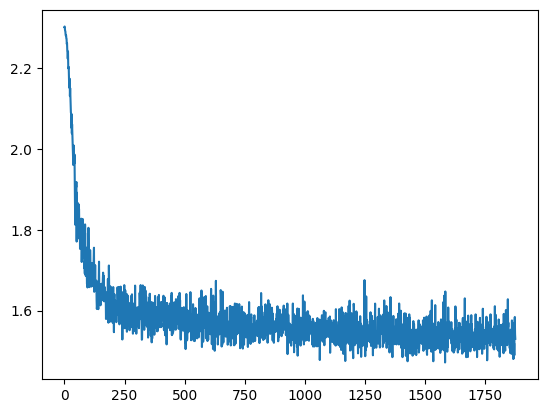

In [6]:
# Parameters
batch_size = 64

# Create train set
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation(degrees=5)
])

# Download MNIST dataset train set, specify transforms
mnist_dataset_train = torchvision.datasets.MNIST(root='../data', # where to download
                                                 train=True, # get train set
                                                 transform=transform_train, # which transforms to apply
                                                 download=True)
# Create a dataloader, specify batch size, shuffle order
mnist_loader_train = DataLoader(mnist_dataset_train,
                                batch_size=batch_size,
                                shuffle=True)

# Create test set
transform_test = transforms.Compose([
    transforms.ToTensor()
])
mnist_dataset_test = torchvision.datasets.MNIST(root='../data',
                                                train=False,
                                                transform=transform_test)
# Create a dataloader, specify batch size, no shuffling
mnist_loader_test = DataLoader(mnist_dataset_test,
                               batch_size=batch_size,
                               shuffle=False)

# Create model
mnist_simpleMLP = SimpleMLP(28*28, 64)
mnist_simpleMLP.to(device)

# Make optimizer and loss
optimizer = torch.optim.Adam(mnist_simpleMLP.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train model
mnist_simpleMLP_history = train_and_test(mnist_simpleMLP, mnist_loader_train, mnist_loader_test, 2, criterion, optimizer, device)

# Plot learning curve
plt.plot(mnist_simpleMLP_history)
plt.show()

Now that we have our trained model, let's look at its activities!

Fortunately, pytorch has some handy functions for this. Here is how it works:

1. Each pytorch layer in the model has a name.
2. We can get the names using the get_graph_node_names() function.
3. Then, we can use the create_feature_extractor() function to get a feature extractor.
4. We can use the feature extractor to get activations of the network for any input we like!

---

Let's look at the layer names in our little network.
>*Note:* We need to import the create_feature_extractor and get_graph_node_names functions as shown here.

In [7]:
from torchvision.models.feature_extraction import create_feature_extractor, get_graph_node_names
model_layer_names, _ = get_graph_node_names(mnist_simpleMLP)
print(model_layer_names)

['x', 'flatten', 'hidden', 'relu', 'output', 'softmax']


>*Quick test:* look at the model definition and find what exactly in the model code these names correspond to.

We could look at activities for any one of these layers. For now, let's look at "hidden".



In [8]:
model_layer = "hidden"
feature_extractor = create_feature_extractor(mnist_simpleMLP, return_nodes=[model_layer])

# get a batch of images
input_images, _ = next(iter(mnist_loader_test))
input_images = input_images.to(device)

# Now that we have the feature extractor, we can use it easily as follows
activations = feature_extractor(input_images)[model_layer]
print(activations.shape)

torch.Size([64, 64])


>*Quick test:* Does the printed shape make sense? Why? What are the rows and what are the columns?

---

That gave us the activities only for one batch. Below is a function to get activities on an entire dataset (i.e., all batches of a dataloader).

Look at the code and make sure you get the idea.

In [9]:
def get_activations(feature_extractor, model_layer, data_loader):

    # make an empty list to collect our activities
    activations = []

    # put the feature extractor model in evaluation mode (see session on
    # training/testing for explanations of what this means)
    feature_extractor.eval()

    # Run the model on the data_loader (torch.no_grad() disables gradient
    # computations, as they are not needed since we are not training here)
    with torch.no_grad():
        for item in tqdm(data_loader, desc='Extracting activities...'):
            imgs, labels = item
            imgs = imgs.to(device)
            these_acts = feature_extractor(imgs)[model_layer].detach().cpu().numpy().flatten()
            activations.append(these_acts.reshape(imgs.shape[0], -1))

    # Concatenate all collected activations
    activations = np.concatenate(activations, axis=0)
    return activations

##Exercise 2:
Now use this function to collect all activities on the mnist test set.

Print the shape of the resulting activities and interpret what it means.

In [10]:
# Extract activities from the first hidden layer on the test set
activations = get_activations(feature_extractor, model_layer, mnist_loader_test)
print(f'Shape of activations: {activations.shape}')

Extracting activities...:   0%|          | 0/157 [00:00<?, ?it/s]

Shape of activations: (10000, 64)


Now that we have all these activities, how can we analyse them? Well, that's an entire field of research. For now, let's do a few simple things.

First, let's try PCA. As we discussed last semester, PCA can be used to visualize high-dimensional data in a 2D plot, by only keeping the first two principal components. Revisit last semester's course if you need a refresher.

In our case, we have n_hidden_units-dimensional data (i.e., we have the activities for the 64 units in our simpleMLP's hidden layer for each MNIST test image). We will apply PCA and use the first 2 PCs to make a scatter plot.

We'll implement it in a function so we can use it again later.

>*Note:* We will color the dots in our PCA scatter plot depending on the labels, which will allow us to see if activities corresponding to different labels cluster together.

/tmp/ipykernel_110008/3037354707.py:20: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(mnist_dataset_test.targets)


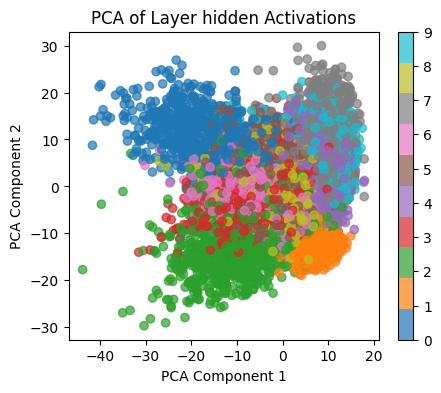

In [11]:
# Run PCA
from sklearn.decomposition import PCA

def plot_pca(activations, labels, name):
    # Run PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(activations)

    # Plot PCA results
    plt.figure(figsize=(5, 4))
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='tab10', alpha=0.7)
    plt.colorbar(scatter, ticks=range(10))
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title(f'PCA of Layer {name} Activations')
    plt.show()


# get the labels for the test set (used for our plot later)
labels = np.array(mnist_dataset_test.targets)


plot_pca(activations, labels, model_layer)

>*Quick test:* Can you interpret this plot? What does it tell you?

---
##Exercise 3:

As discussed last semester, there are other dimensionality reduction techniques. Make a similar plot as above but using TSNE, by importing the relevant sklearn function. This is exactly analoguous to the previous code for PCA. Look at online documentation or ask an AI assistant if needed.

Warning: this TSNE can take a bit of time to run,

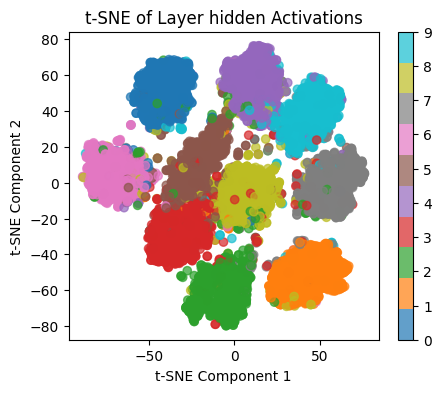

In [12]:
from sklearn.manifold import TSNE

def plot_tsne(activations, labels, name):
  # Run t-SNE
  tsne = TSNE(n_components=2, random_state=42)
  tsne_result = tsne.fit_transform(activations)

  # Plot t-SNE results
  plt.figure(figsize=(5,4))
  scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap='tab10', alpha=0.7)
  plt.colorbar(scatter, ticks=range(10))
  plt.xlabel('t-SNE Component 1')
  plt.ylabel('t-SNE Component 2')
  plt.title(f't-SNE of Layer {name} Activations')
  plt.show()

plot_tsne(activations, labels, model_layer)

>*Quick test*: Are the results compatible with the previous PCA?

---

##Exercise 4
Finally, let's apply Representational Similarity Analysis (RSA). We covered theory about RSA in depth last semester.

Here, we will sort our activities by label (i.e., first all the activities for 0s, then 1s, etc.), and make a "Representational Dissimilarity Matrix" (RDM) showing how dissimilar activities for different stimuli are.

RDMs can be computed in one line of code using the ```pdist``` function from from ```scipy.spatial.distance```. This function returns the upper triangle of the RDM, so we need to use ```squareform``` to transform it into the full RDM.

<Figure size 500x400 with 0 Axes>

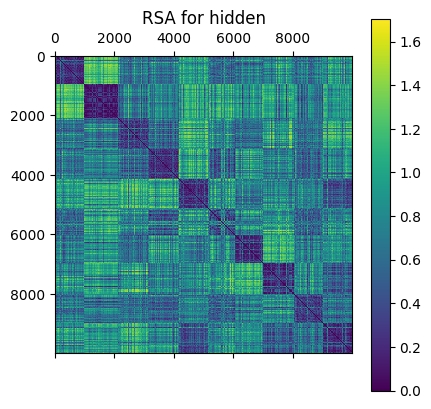

In [13]:
from scipy.spatial.distance import pdist, squareform

def plot_rsa(activations, labels, name):
  # Arrange data by label, and run RSA
  sorted_indices = np.argsort(labels)  # Get indices that would sort the labels array

  # Sort both data and labels using the sorted indices
  sorted_activations = activations[sorted_indices]
  sorted_labels = labels[sorted_indices]

  # Calculate pairwise distances using pdist
  pairwise_distances = pdist(sorted_activations, 'correlation')
  plt.figure(figsize=(5,4))
  plt.matshow(squareform(pairwise_distances))
  plt.title(f'RSA for {name}')
  plt.colorbar()
  plt.show()

plot_rsa(activations, labels, model_layer)

You should see a patchy structure with squares.

>*Quick test:* What does this structure tell you? (Hint: this depends on how we ordered our stimuli when creating the RDM).

##Exercise 4: untrained model

Now make a new instance of your SimpleMLP class (call it ```mnist_simpleMLP_untrained```), and do NOT train it.

Extract its activities (following the steps used earlier for the trained model) and run PCA and RSA (using the functions defined above). Think about the results and what they tell us.

Extracting activities...:   0%|          | 0/157 [00:00<?, ?it/s]

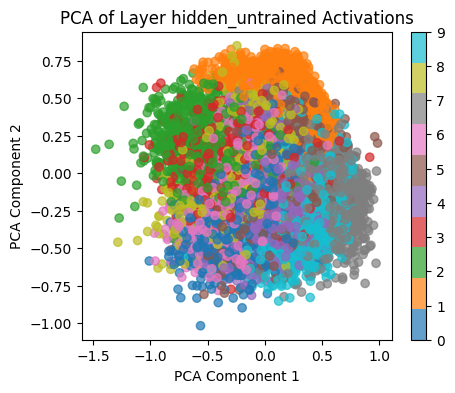

<Figure size 500x400 with 0 Axes>

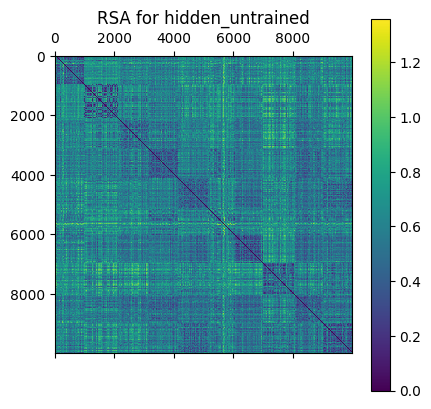

In [14]:
# new model instance
mnist_simpleMLP_untrained = SimpleMLP(28*28, 64)
mnist_simpleMLP_untrained.to(device)

# make feature extractor
feature_extractor_untrained = create_feature_extractor(mnist_simpleMLP_untrained, return_nodes=['hidden'])

# get activations from the feature extractor
activations_untrained = get_activations(feature_extractor_untrained, 'hidden', mnist_loader_test)

# PCA
plot_pca(activations_untrained, labels, 'hidden_untrained')

# RSA
plot_rsa(activations_untrained, labels, 'hidden_untrained')

#Using big pretrained models

## Where to find pretrained models

There are many different places to download models, each with their own specific interfaces. In this course, we will focus on models provided by pytorch, for simplicity. But feel free to explore other places, especially HuggingFace. Below are some resources to find models.


| **Location** | **What's there?** | **Link(s)** |
| ----- | ----- | ----- |
| **PyTorch domain libraries** | Each of the PyTorch domain libraries (`torchvision`, `torchtext`) come with pretrained models of some form. The models there work right within PyTorch. | [`torchvision.models`](https://pytorch.org/vision/stable/models.html), [`torchtext.models`](https://pytorch.org/text/main/models.html), [`torchaudio.models`](https://pytorch.org/audio/stable/models.html), [`torchrec.models`](https://pytorch.org/torchrec/torchrec.models.html) |
| **HuggingFace Hub** | A series of pretrained models on many different domains (vision, text, audio and more) from organizations around the world. There's plenty of different datasets too. | https://huggingface.co/models, https://huggingface.co/datasets |
| **`timm` (PyTorch Image Models) library** | Computer vision models in PyTorch code as well as plenty of other helpful computer vision features. | https://github.com/rwightman/pytorch-image-models|
| **Paperswithcode** | Machine learning papers with code implementations attached. You can also find benchmarks here of model performance on different tasks. | https://paperswithcode.com/ |

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/06-transfer-learning-where-to-find-pretrained-models.png" alt="different locations to find pretrained neural network models" width=900/>

> **Exercise:** Spend 5-minutes going through [`torchvision.models`](https://pytorch.org/vision/stable/models.html) as well as the [HuggingFace Hub Models page](https://huggingface.co/models), what do you find? (there's no right answers here, it's just to practice exploring)

With that said, as mentioned, we will focus on the pytorch ecosystem here.

---

We are now going to download a big model trained on lots of data: a powerful vision ANN, which has learnt to extract good features for visual tasks.

As mentioned, there are many online repositories full of models, and they each have their own interface. Here we will deal with pytorch, and in particular torchvision v0.13+ (i.e., version 0.13 or greater). If you use a lower version, things may not work out.

---

You can find documentation about which models are available in pytorch and how to use them [here](https://pytorch.org/vision/stable/models.html). The pretrained model we're going to be using is [`torchvision.models.resnet18()`](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html). ResNets are a famous and widely used family of models. ResNet18 is a resonably sized one, which will allows us to run it reasonably quickly on this small computer.


There are two main steps to get the model:
1. Get the saved model `weights` (in our case using `ResNet18_weights = torchvision.models.ResNet18_Weights.DEFAULT
`): This returns an object that contains a lot of information about the trained model, including the model weights themselves. In addition, we need to make sure that we pre-process the images as expected by the network, otherwise the network will get confused. Fortunately, in pytorch, the `ResNet18_weights` also contain that information, and we can retrieve it easily using `ResNet18_transforms = ResNet18_weights.transforms()`, as shown below.
2. Instead of coding the model definition (as we did earlier for SimpleMLP, CustomMLP, etc), we just get it from pytorch using, in our case `torchvision.models.resnet18(weights=ResNet18_weights))`. We specify ```weights=ResNet18_weights``` to use the pre-trained weights we just got in point 1 above.

---

Let's get the weights, and from them the pre-processing transforms. Then let's get the model instance.

In [15]:
# get the pretrained weights (cf. torchvision online documentation for other models)
ResNet18_weights = torchvision.models.ResNet18_Weights.DEFAULT
print(ResNet18_weights.__dict__) # a quick way to see all the info that is in there

# the weights contain the preprocessing transforms! Very handy.
ResNet18_transforms = ResNet18_weights.transforms()
print(ResNet18_transforms)

# get an instance of ResNet18. THIS IS THE ACTUAL NETWORK
ResNet18_model = torchvision.models.resnet18(weights=ResNet18_weights)

{'_value_': Weights(url='https://download.pytorch.org/models/resnet18-f37072fd.pth', transforms=functools.partial(<class 'torchvision.transforms._presets.ImageClassification'>, crop_size=224), meta={'min_size': (1, 1), 'categories': ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 

100%|██████████| 44.7M/44.7M [00:07<00:00, 6.14MB/s]


This model is big and complicated.

Let's get some information about what this model looks like. For this, we can use a package called torchinfo (and if we don't have it installed, we install it using ```!pip install torchinfo```, which we put in a try/except so we don't install each each time we run this code cell).

In [17]:
# Print a summary using torchinfo
try:
  from torchinfo import summary
except:
  print("[INFO] Couldn't find torchinfo... installing it.")
  !pip install -q torchinfo
  from torchinfo import summary

summary(model=ResNet18_model,
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]    [32, 1000]           --                   True
├─Conv2d (conv1)                         [32, 3, 224, 224]    [32, 64, 112, 112]   9,408                True
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]   [32, 64, 112, 112]   128                  True
├─ReLU (relu)                            [32, 64, 112, 112]   [32, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   True
│    └─BasicBlock (0)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   True
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]     [32, 64, 56, 56]     36,864               True
│    │    └─BatchN

Looking at the `torchinfo.summary`, we see that the ResNet is a complicated combination of convolutional layers, and many more. We will not go into details here. We can also see that there are over 11 million parameters.

Now we are going to take images from the CIFAR10 test set, and pass them through the network. Then we'll run analyses on them.

***This will become very important as we move towards predicting brain activities from model activities! We will often pass some images through a big model like this, and use that to do encoding models or RSA to compare the activities with the brain activities evoked by the same images.***

Let's start by making a Dataset and Dataloader for CIFAR10.

>**Note:** I'm doing it for you to save time but make sure you understand the code. *In particular, make sure you understand why and how we use the transforms provided by the ResNet.*

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7069099..2.5702832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4831376].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..2.5702832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4500387..2.2565577].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..1.7808123].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..1.4782944].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793

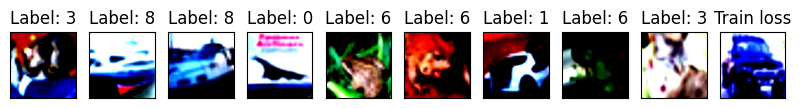

In [18]:
# Train/test Datasets
ResNet18_cifar_test = torchvision.datasets.CIFAR10(root='../data', transform=ResNet18_transforms, download=True, train=False)

# Train/test DataLoaders
ResNet18_cifar_dataloader_test = DataLoader(dataset=ResNet18_cifar_test, batch_size=128, num_workers=2, shuffle=False)

# Print a few samples to make sure all is well
plot_dataset_samples(ResNet18_cifar_dataloader_test, 10)

The first step to analyse layer activities is to choose which layer to look at. Let's print all the layer names as we did for our small network.

In [19]:
from torchvision.models.feature_extraction import create_feature_extractor, get_graph_node_names
model_layer_names, _ = get_graph_node_names(ResNet18_model)
print(model_layer_names)

['x', 'conv1', 'bn1', 'relu', 'maxpool', 'layer1.0.conv1', 'layer1.0.bn1', 'layer1.0.relu', 'layer1.0.conv2', 'layer1.0.bn2', 'layer1.0.add', 'layer1.0.relu_1', 'layer1.1.conv1', 'layer1.1.bn1', 'layer1.1.relu', 'layer1.1.conv2', 'layer1.1.bn2', 'layer1.1.add', 'layer1.1.relu_1', 'layer2.0.conv1', 'layer2.0.bn1', 'layer2.0.relu', 'layer2.0.conv2', 'layer2.0.bn2', 'layer2.0.downsample.0', 'layer2.0.downsample.1', 'layer2.0.add', 'layer2.0.relu_1', 'layer2.1.conv1', 'layer2.1.bn1', 'layer2.1.relu', 'layer2.1.conv2', 'layer2.1.bn2', 'layer2.1.add', 'layer2.1.relu_1', 'layer3.0.conv1', 'layer3.0.bn1', 'layer3.0.relu', 'layer3.0.conv2', 'layer3.0.bn2', 'layer3.0.downsample.0', 'layer3.0.downsample.1', 'layer3.0.add', 'layer3.0.relu_1', 'layer3.1.conv1', 'layer3.1.bn1', 'layer3.1.relu', 'layer3.1.conv2', 'layer3.1.bn2', 'layer3.1.add', 'layer3.1.relu_1', 'layer4.0.conv1', 'layer4.0.bn1', 'layer4.0.relu', 'layer4.0.conv2', 'layer4.0.bn2', 'layer4.0.downsample.0', 'layer4.0.downsample.1', 'lay

Every network is different, and there is no uniform naming convention. Each time we download a network, it can be a challenging to understand the architecture, and which layer names correspond to which layer. Comparing the layer names to the network summary we printed earlier is helpful to get our bearings.

Here, we are going to analyse an early layer and compare that to a late layer, to check if later layers are better at getting to the abstract category information.

Let's start with a late layer: `avgpool`.

>**Quick test:** Look at our `torchinfo.summary` from earlier, and make sure you understand why `layer_name = 'avgpool'` will get us a late layer of the network. You could even try to figure out which layer of the summary exactly it is. *Make sure you are comfortable getting the activities you want, as this will be important moving forward.*

###Incremental PCA for our DNN activations.

Now we reach a slightly complicated technical point. Let me explain.

>**Note:** This is a technical point we *must* deal with, which is why I am presenting it here. But the details of the following are not required knowledge for the course. Ultimately, we'll write a function called ```get_pca_activities()``` which you can just always use in the future without worrying too much about the following points. <font color='red'>***Therefore, understanding the following is optional.*** **If you want, you can skip the following and go directly to the next cell.**</font>

Some layers are very big. For example, consider the layer: `Con2d (conv1)`. If we look at the summary, we can see that this layer has 64 channels, 112 height, 112 width. That's 64\*112\*122 = 874'496 units! That's a lot.

Previously, we just extracted the network activities without any further processing. However, if we have too many artificial neuron activities, we will not be able to fit everything in memory. You can try it for yourself: if you chose a layer with a lot of neurons (such as the `Con2d (conv1)` we are considering), and try to extract all activities at once, your notebook will crash because you'll run out of memory.

To avoid this issue, we use [principal component analysis](https://peterbloem.nl/blog/pca) (PCA), which, as discussed last semester, is a common form of dimensionality reduction. We will reduce the dimensionality of our network activations to 50, a more manageable number.

Another issue is that we cannot use "normal" PCA because, again, we don't have enough memory to do that. Indeed, computing PCA requires loading all the data in memory, but we can't do it. To circumvent this issue, we'll now apply *incremental PCA*, which approximates true PCA but operates over smaller batches instead of on the whole `[n_stimuli x n_layer_activities]` matrix.

We will define a function that does the following:

0. Declare an IncrementalPCA instance.
1. Loops over batches of images.
2. For each batch, we extract the DNN activities, yielding an [`n_batch_imgs, n_layer_activities]` matrix.
3. Apply one step of incremental pca to that batch of activities
4. The function returns the fitted PCA instance.

Then, we'll use that function to apply PCA to the network activities we collect.
\
**NOTE 1:** The 50 dimensions is just a ballpark estimate of the number of dimensions. A more principled approach would be to set a threshold proportion (e.g. 90%) of variance explained in the original data (network activations) and use the number of dimensions needed to reach that (e.g. see [this tutorial](https://www.geo.fu-berlin.de/en/v/soga-py/Advanced-statistics/Multivariate-Approaches/Principal-Component-Analysis/PCA-the-basics/Choose-Principal-Components/index.html#:~:text=A%20widely%20applied%20approach%20is,elbow%20in%20the%20scree%20plot.)). Here, we don't need to worry about that.

**NOTE 2:** All this may be confusing: here is your periodic reminder to ***ask questions if you feel lost!***

In [20]:
from sklearn.decomposition import IncrementalPCA

# First we define a function that fits our incremental PCA
def fit_pca(feature_extractor, dataloader, batch_size, device, n_components=50):

    # Define PCA parameters
    pca = IncrementalPCA(n_components, batch_size=batch_size)

    # Fit PCA to batch
    with torch.no_grad():
        for item in tqdm(dataloader, desc='Fitting incremental PCA...'):

            imgs, labels = item
            imgs = imgs.to(device)

            if imgs.shape[0] < n_components:
                # check if our batch size is at least as large as n_components
                # the last batch can be smaller. If it is smaller than n_components,
                # PCA cannot run so we skip
                continue
            # Extract features
            ft = feature_extractor(imgs)
            # Flatten the features
            ft = torch.hstack([torch.flatten(l, start_dim=1) for l in ft.values()])
            # Fit PCA to batch
            pca.partial_fit(ft.detach().cpu().numpy())

    return pca


# Second, we define a function that does the following:
# 1. Check if we have fitted the PCA already (e.g. because this is the second
# time we extract activities). If so, we use the fitted PCA. Otherwise, we call
# the above function to fit the PCA.
# 2. We get each batch in our dataset, get retrieve the corresponding network
# activities (as done before in our get_activations() function), and apply
# our PCA to it. That will reduce the dimensionality of the batch as required.
def get_pca_activities(feature_extractor, dataloader, device, pca=None):

    if pca is None:
        # Fit PCA
        pca = fit_pca(feature_extractor, dataloader, 50, device)

    features = []
    with torch.no_grad():
        for item in tqdm(dataloader, desc='Extracting activities...'):
            imgs, labels = item
            imgs = imgs.to(device)
            # Extract features
            ft = feature_extractor(imgs)
            # Flatten the features
            ft = torch.hstack([torch.flatten(l, start_dim=1) for l in ft.values()])
            # Apply PCA transform
            ft = pca.transform(ft.cpu().detach().numpy())
            features.append(ft)
    return np.vstack(features), pca

In the future, you can always use this ```get_pca_activities()``` function to get activities. You can just assume it works and apply it always.

Let's use it to get the activities for the ```avgpool``` layer.

For this:
1. We define a feature_extractor for this layer.
2. We call our new function.

>**Note**: The first time you run this, it will take a bit of time. For larger layers it will take even longer. That's life in computational cognitive neuroscience :(. So now is a good time to get coffee :). This is where you will see the benefit of using GPUs. With a GPU this takes under 2min. Without a GPU, it takes over 20min.

In [21]:
layer_name = 'avgpool'
feature_extractor_avgpool = create_feature_extractor(ResNet18_model, return_nodes=[layer_name])
ResNet18_activations_avgpool, pca_avgpool = get_pca_activities(feature_extractor_avgpool, ResNet18_cifar_dataloader_test, device)
print(ResNet18_activations_avgpool.shape)

Fitting incremental PCA...:   0%|          | 0/79 [00:00<?, ?it/s]

Extracting activities...:   0%|          | 0/79 [00:00<?, ?it/s]

(10000, 50)


>Quick test: What does the printed shape tell you?
1. Which dimension corresponds to the number of images for which we got activations?
2. Which dimension corresponds to the number of units in the network layer we read out?

>Answer:
1. We used the get_activations() function defined earlier to get activities. We passed it our CIFAR10 dataloader for the test set. That means that we got activities for the entire test set, which is 10'000 images. So the first dimension reflects these 10'000 images.
2. The second dimension corresponds to the 50 PCs we keep after applying PCA to the `avgpool` units. I.e., these are the network activities after applying PCA.
3. So in summary, each row corresponds to all the PCA-ed activities for a given image from the CIFAR10 test set.

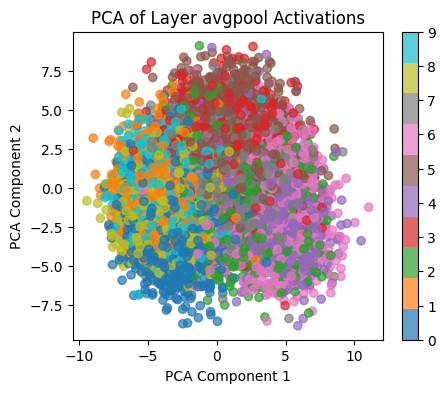

<Figure size 500x400 with 0 Axes>

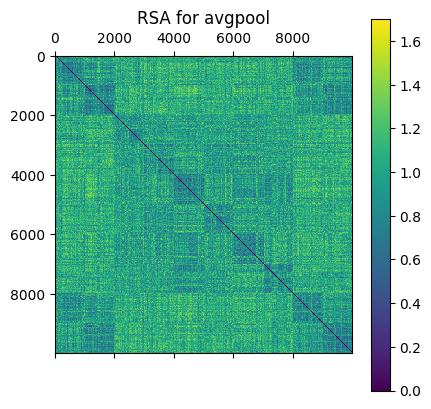

In [22]:
labels = np.array(ResNet18_cifar_test.targets)

plot_pca(ResNet18_activations_avgpool, labels, layer_name)
plot_rsa(ResNet18_activations_avgpool, labels, layer_name)

Do the plots make sense? What do you think?

##Compact summary
...phew that was a lot. But, now we have all the tools we need to easily retrieve activities from pre-trained networks from the internet!

Below is compact code showing you how to do this. In the future, if you want to retrieve activities from any layer of any model available online from pytorch, you can follow these simple steps.

['x', 'conv1', 'bn1', 'relu', 'maxpool', 'layer1.0.conv1', 'layer1.0.bn1', 'layer1.0.relu', 'layer1.0.conv2', 'layer1.0.bn2', 'layer1.0.add', 'layer1.0.relu_1', 'layer1.1.conv1', 'layer1.1.bn1', 'layer1.1.relu', 'layer1.1.conv2', 'layer1.1.bn2', 'layer1.1.add', 'layer1.1.relu_1', 'layer2.0.conv1', 'layer2.0.bn1', 'layer2.0.relu', 'layer2.0.conv2', 'layer2.0.bn2', 'layer2.0.downsample.0', 'layer2.0.downsample.1', 'layer2.0.add', 'layer2.0.relu_1', 'layer2.1.conv1', 'layer2.1.bn1', 'layer2.1.relu', 'layer2.1.conv2', 'layer2.1.bn2', 'layer2.1.add', 'layer2.1.relu_1', 'layer3.0.conv1', 'layer3.0.bn1', 'layer3.0.relu', 'layer3.0.conv2', 'layer3.0.bn2', 'layer3.0.downsample.0', 'layer3.0.downsample.1', 'layer3.0.add', 'layer3.0.relu_1', 'layer3.1.conv1', 'layer3.1.bn1', 'layer3.1.relu', 'layer3.1.conv2', 'layer3.1.bn2', 'layer3.1.add', 'layer3.1.relu_1', 'layer4.0.conv1', 'layer4.0.bn1', 'layer4.0.relu', 'layer4.0.conv2', 'layer4.0.bn2', 'layer4.0.downsample.0', 'layer4.0.downsample.1', 'lay

Fitting incremental PCA...:   0%|          | 0/79 [00:00<?, ?it/s]

Extracting activities...:   0%|          | 0/79 [00:00<?, ?it/s]

(10000, 50)


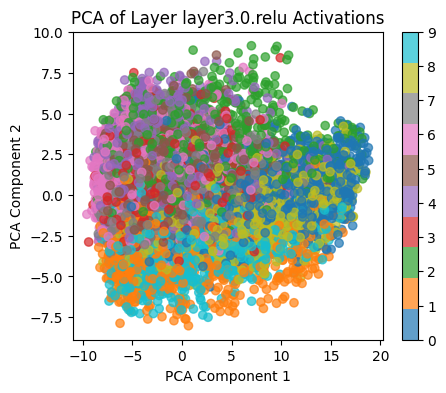

<Figure size 500x400 with 0 Axes>

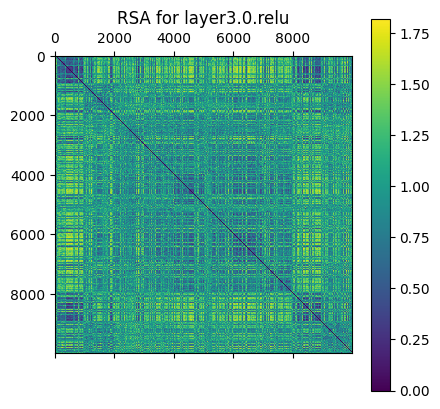

In [23]:
# Download model, make model instance, put it on the right device
ResNet18_weights = torchvision.models.ResNet18_Weights.DEFAULT
ResNet18_transforms = ResNet18_weights.transforms()
ResNet18_model = torchvision.models.resnet18(weights=ResNet18_weights)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ResNet18_model.to(device)
ResNet18_model.eval()

# Print available layers
model_layer_names, _ = get_graph_node_names(ResNet18_model)
print(model_layer_names)

# Choose layer to analyse and make feature extractor
layer_name = 'layer3.0.relu'
ResNet18_feature_extractor_l3 = create_feature_extractor(ResNet18_model, return_nodes=[layer_name])

# Make dataloaders with approprate transforms
ResNet18_cifar_test = torchvision.datasets.CIFAR10(root='../data', transform=ResNet18_transforms, download=True, train=False)
ResNet18_cifar_dataloader_test = DataLoader(dataset=ResNet18_cifar_test, batch_size=128, num_workers=2, shuffle=False)

# Extract activations
ResNet18_activations_l3, pca_l3 = get_pca_activities(ResNet18_feature_extractor_l3, ResNet18_cifar_dataloader_test, device)
print(ResNet18_activations_l3.shape)

# Reduce dimensionality and analyse
plot_pca(ResNet18_activations_l3, labels, layer_name)
plot_rsa(ResNet18_activations_l3, labels, layer_name)

##Exercise 5:

Let's extract activities for the AlexNet CNN. This is a classic network that many people use.

1. Go to the torchvision [website](https://pytorch.org/vision/stable/models.html) find Alexnet.
2. Download it, using analoguous steps steps as we did for ResNet18.
4. Retreive activities for the CIFAR10 test set from a layer of your choice, and analyse them with PCA and RSA.

***NOTE: I would like to stress that it is important that you feel confident with these steps, because your project will require you to get activities from different models and compare how well they match brain activities.***

*Bonus: repeat, but with another dataset from the ones available in pytorch.*

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /home/chuddy/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:40<00:00, 6.07MB/s] 


['x', 'features.0', 'features.1', 'features.2', 'features.3', 'features.4', 'features.5', 'features.6', 'features.7', 'features.8', 'features.9', 'features.10', 'features.11', 'features.12', 'avgpool', 'flatten', 'classifier.0', 'classifier.1', 'classifier.2', 'classifier.3', 'classifier.4', 'classifier.5', 'classifier.6']


Fitting incremental PCA...:   0%|          | 0/79 [00:00<?, ?it/s]

Extracting activities...:   0%|          | 0/79 [00:00<?, ?it/s]

(10000, 50)


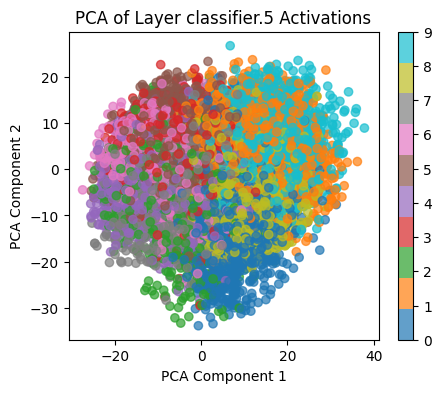

<Figure size 500x400 with 0 Axes>

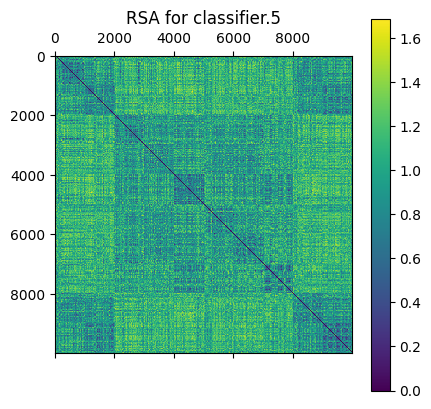

In [24]:
# Download model, make model instance, put it on the right device
AlexNet_weights = torchvision.models.AlexNet_Weights.DEFAULT
AlexNet_transforms = AlexNet_weights.transforms()
AlexNet_model = torchvision.models.alexnet(weights=AlexNet_weights)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AlexNet_model.to(device)
AlexNet_model.eval()

# Print available layers
alexnet_layer_names, _ = get_graph_node_names(AlexNet_model)
print(alexnet_layer_names)

# Choose layer to analyse and make feature extractor
layer_name = 'classifier.5'  # Pre-readout fully connected layer
AlexNet_feature_extractor = create_feature_extractor(AlexNet_model, return_nodes=[layer_name])

# Make dataloaders with appropriate transforms
AlexNet_cifar_test = torchvision.datasets.CIFAR10(root='../data', transform=AlexNet_transforms, download=True, train=False)
AlexNet_cifar_dataloader_test = DataLoader(dataset=AlexNet_cifar_test, batch_size=128, num_workers=2, shuffle=False)

# Extract activations
AlexNet_activations, pca = get_pca_activities(AlexNet_feature_extractor, AlexNet_cifar_dataloader_test, device)
print(AlexNet_activations.shape)

# Reduce dimensionality and analyse
plot_pca(AlexNet_activations, labels, layer_name)
plot_rsa(AlexNet_activations, labels, layer_name)

##Bonus:
This sort of short code to get network activities will be important for your project. If you feel uncomfortable, try it out with other networks, other layers, other datasets, etc.